PROJECT: Medical Insurance Cost Prediction

Dataset: insurance.csv

**1. Setup**

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [51]:
# Configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = "insurance.csv"
TARGET_COL = "charges"

**2. Load Dataset**

In [52]:
df = pd.read_csv(CSV_PATH)

In [53]:
print("Dataframe Shape:", df.shape)

Dataframe Shape: (1338, 7)


**3. Exploratory Data Analysis (EDA)**

In [54]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [55]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [57]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Target Column:", TARGET_COL)
print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Target Column: charges
Numerical Columns: ['age', 'bmi', 'children', 'charges']
Categorical Columns: ['sex', 'smoker', 'region']


In [58]:
# Missing values Analysis
print("Missing Values Per Column:")
print(df.isnull().sum())

Missing Values Per Column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [59]:
# Check Presence of encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(3))

age
18    69
19    68
46    29
Name: count, dtype: int64
sex
male      676
female    662
Name: count, dtype: int64
bmi
32.300    13
28.310     9
28.880     8
Name: count, dtype: int64
children
0    574
1    324
2    240
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
Name: count, dtype: int64
charges
1639.563     2
16884.924    1
1725.552     1
Name: count, dtype: int64


No missing values in the dataset

In [60]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of Duplicate Rows:", num_duplicates)

# # if missing values
# df = df.drop_duplicates()
# print("Shape after dropping duplicates:", df.shape)

Number of Duplicate Rows: 1


In [61]:
# describe stat
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.000,39.207,14.050,18.000,27.000,39.000,51.000,64.000
bmi,1338.000,30.663,6.098,15.960,26.296,30.400,34.694,53.130
children,1338.000,1.095,1.205,0.000,0.000,1.000,2.000,5.000
charges,1338.000,13270.422,12110.011,1121.874,4740.287,9382.033,16639.913,63770.428


In [62]:
# describe stat
df[cat_cols].describe().T

,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


In [63]:
# categorical columns analysis
for col in cat_cols:
    print(df[col].value_counts())

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


Data Visualization

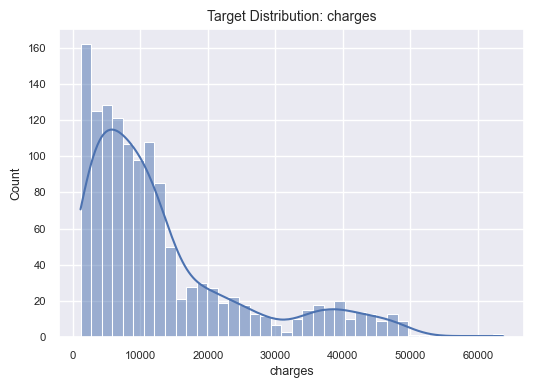

In [64]:
# Targe Column Distribution
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COL], bins=40, kde=True)
plt.title(f"Target Distribution: {TARGET_COL}")
plt.xlabel(TARGET_COL)
plt.show()

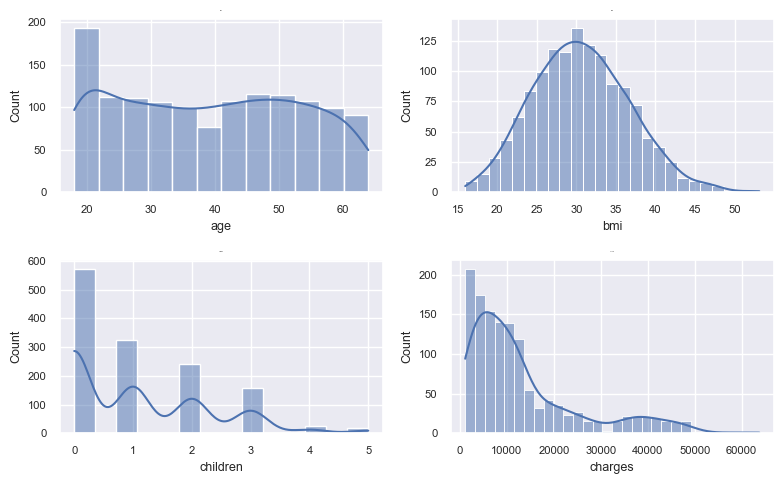

In [65]:
# Histogram plot - Distribution
fig, axes = plt.subplots(2, 2, figsize=(8,5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=0)

plt.tight_layout()
plt.show()

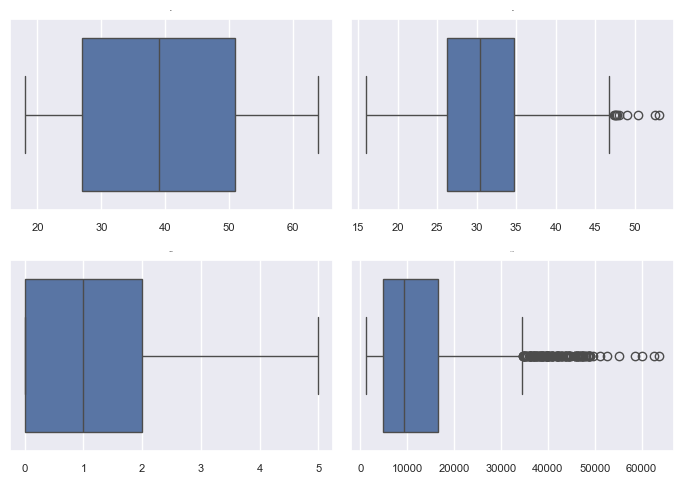

In [66]:
# Outlier analysis - Boxplot
fig, axes = plt.subplots(2, 2, figsize=(7,5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=0)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

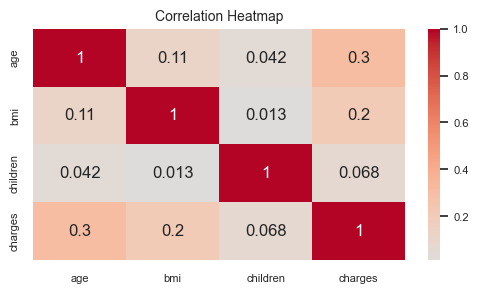

In [67]:
# identify prescence of highly correlated columns & feature relationship
plt.figure(figsize=(6,3))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

We don't have much correlated columns

In [68]:
# correlation with target
corr_with_target= df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("Correlation With Target:")
print(corr_with_target)

Correlation With Target:
charges    1.000
age        0.299
bmi        0.198
children   0.068
Name: charges, dtype: float64


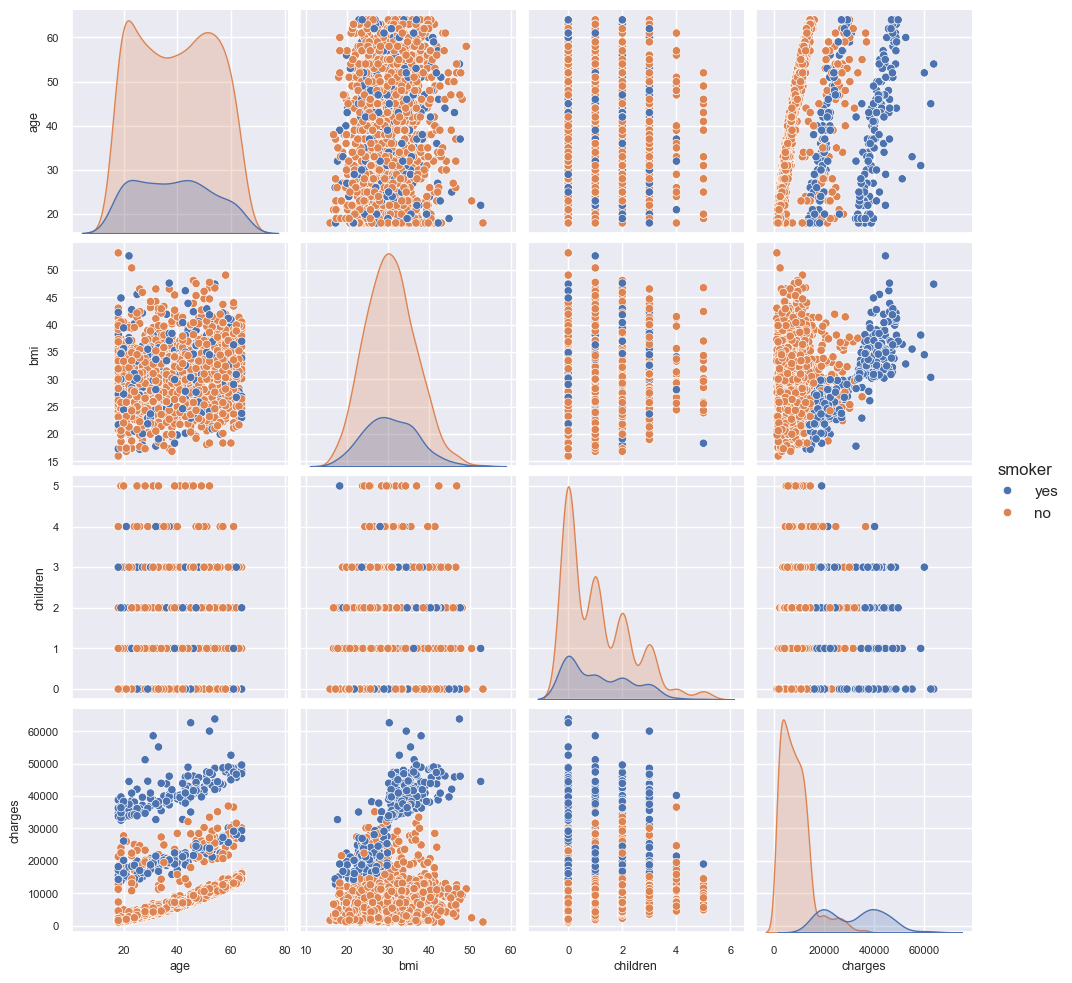

In [69]:
# pair plot
pairplot_cols = num_cols + ["smoker"]

df_pair = df[pairplot_cols].dropna()

sns.pairplot(df_pair, hue="smoker")
plt.show()

Key Insights from EDA
- Dataset contains a mix of numerical features (age, bmi, children) and categorical features (sex, smoker, region)
- No missing values detected in any column
- Target variable charges is highly right-skewed with a small numbe of extreme high-cost outliers
- Smoker status shows a very strong seperation in the charges distribution
- Age and BMI show moderate positive correlation with charges
- No evere multicolinearity among numerical features
- Outliers are prominent in charges ( and to a lesser extent BMI), especially for smokers

_________

Preprocessing & Evaluation Plan
- No missing value imputation required
- One-hot encode categorical variables (sex, smoker, region)
- Feture scaling applied for linear and regularized models (for tree based model we can skip this)
- No aggressive outlier removal, to preserve real world high-cost medical cases
- Use pipelines and columnTraansformer to prevent data Leakages
- Baseline model using Linear Regression
- Model comparison using cross validation
- Tree-based models explored to capture non-linear relationships
- Apply log transformation on the target variable (charges) to handle skewness
- Primary evaluation metric: MAE (robust to extreme outliers)
- Secondary metrics: RMSE and R2 (to understand worst-case errors and variance explained)
- Hyperparameter tuning performed only on top-performing models
- Final evaluation conducted strictly on a held-out test set

**4. Data Preprocessing**

In [70]:
# seperate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [71]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [72]:
y.head()

0   16884.924
1    1725.552
2    4449.462
3   21984.471
4    3866.855
Name: charges, dtype: float64

In [73]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [74]:
print("Train Shape:", X_train.shape)

print("Test Shape:", X_test.shape)

Train Shape: (1070, 6)
Test Shape: (268, 6)


**Preprocessing Pipeline**

In [75]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

# Numerical features - preprocessing steps
# imputers can be added in numerical transformer
numerical_tranformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Categorical features - preprocessing steps
categorical_transformers = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))

    ]
)

# Preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_tranformer, numerical_features),
        ("cat", categorical_transformers, categorical_features)
    ]
)

Numerical Features: ['age', 'bmi', 'children']
Categorical Features: ['sex', 'smoker', 'region']


**5. Baseline Model (No CV, No Tuning)**

In [76]:
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

In [77]:
# preprocess the data and train the baseline model
baseline_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

Evaluation of baseline Model

In [78]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [79]:
train_baseline_pred[:5]

array([ 7094.54007011,  8344.72998713,  9153.77419778, 11128.37948103,
       10088.00517924])

In [80]:
X_train[:5]

,age,sex,bmi,children,smoker,region
560,46,female,19.950,2,no,northwest
1285,47,female,24.320,0,no,northeast
1142,52,female,24.860,0,no,southeast
969,39,female,34.320,5,no,southeast
486,54,female,21.470,3,no,northwest


In [81]:
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("== TRAIN BASELINE METRICS (LinearRegression) ==")
print(f"MAE : {train_baseline_mae:.3f}")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"R2  : {train_baseline_r2:.3f}")

== TRAIN BASELINE METRICS (LinearRegression) ==
MAE : 4208.235
RMSE: 6105.545
R2  : 0.742


In [82]:
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("== TEST BASELINE METRICS (LinearRegression) ==")
print(f"MAE : {test_baseline_mae:.3f}")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"R2  : {test_baseline_r2:.3f}")

== TEST BASELINE METRICS (LinearRegression) ==
MAE : 4181.194
RMSE: 5796.285
R2  : 0.784


**6. Model Selection and optimization**

In [83]:
# models to try
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "DecisionTree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor()
}

In [84]:
k=5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [85]:
scoring= {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

neg_mean_absolute_error  --- "neg" error metrics because once we move to the next step which is model optimization (GridsearchCV -- thinks if the score is high then the model is better) ---- in regression if the error metrics are higher it doesn't mean the model is performing better but when the metrics are low then it is performing well- ----- so we invert it with "neg"

In [86]:
rows = []

for name, model in models.items():
    pipe=Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({
        "model":name,
        "cv_mae": -scores["test_mae"].mean(),
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_r2": scores["test_r2"].mean()
    })

# sort based on lowest to highest
cv_results = pd.DataFrame(rows).sort_values("cv_mae")
print("== CV MODEL Comparison ==")
print(cv_results)

c:\Users\Lenovo\Documents\Udemy\Machine learning bootcamp\section_15\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


== CV MODEL Comparison ==
              model   cv_mae  cv_rmse  cv_r2
4      RandomForest 2750.344 4890.766  0.834
3      DecisionTree 3062.401 6509.477  0.705
5           XGBoost 3171.958 5454.891  0.793
2             Lasso 4234.960 6123.254  0.739
0  LinearRegression 4234.984 6123.354  0.739
1             Ridge 4240.596 6123.344  0.739


In [87]:
best_row = cv_results.sort_values("cv_mae").iloc[0]

best_model_name = best_row["model"]
best_mae = best_row["cv_mae"]

print("Best Modle Based On CV MAE:")
print("Model  :", best_model_name)
print("CV MAE :", best_mae)

Best Modle Based On CV MAE:
Model  : RandomForest
CV MAE : 2750.3440279698916


**BEST MODEL: RandomForestRegressor**

**7. Hyperparameter Tuning**

In [88]:
rf_pipe =Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=1
        ))
    ]
)

In [98]:
# Hyperparameter combination
param_grid_rf = {
    "model__n_estimators": [200, 300, 600, 900],
    "model__max_depth": [None, 8, 15, 25],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.6, 0.8],
    "model__bootstrap": [True],
}

In [99]:
grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

In [100]:
# Perform Grid Search
grid.fit(X_train, y_train)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.4s finished


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__bootstrap': [True], 'model__max_depth': [None, 8, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the

In [102]:
print("== TUNED UP (CV) ==")
print("Best CV MAE:", -grid.best_score_)
print("Best Params:", grid.best_params_)

== TUNED UP (CV) ==
Best CV MAE: 2572.71836170844
Best Params: {'model__bootstrap': True, 'model__max_depth': 8, 'model__max_features': 0.6, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}


**9. Retraining with best params**

In [105]:
rf_best = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            bootstrap=True,
            max_depth=8,
            max_features=0.8,
            min_samples_split=2,
            min_samples_leaf=4,
            n_estimators=200,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=1
        ))
    ]
)

In [106]:
# train best model on entire training data ( can also be done with refit=True in grid search)
rf_best.fit(X_train, y_train)   

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.1s finished


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [107]:
train_final_pred = rf_best.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_baseline_pred)

print("== FINAL MODEL (Tuned RF) --> Train Performance ==")
print(f"MAE  : {train_final_mae:.3f}")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"R2  : {train_final_r2:.3f}")

== FINAL MODEL (Tuned RF) --> Train Performance ==
MAE  : 2018.653
RMSE: 3672.611
R2  : 0.742


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished


In [108]:
test_final_pred = rf_best.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_baseline_pred)

print("== FINAL MODEL (Tuned RF) --> Test Performance ==")
print(f"MAE  : {test_final_mae:.3f}")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"R2  : {test_final_r2:.3f}")

== FINAL MODEL (Tuned RF) --> Test Performance ==
MAE  : 2417.472
RMSE: 4329.268
R2  : 0.784


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished


**Apply Log Transformation on Target**

In [109]:
rf_best_log = TransformedTargetRegressor(
    regressor=Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(
                bootstrap=True,
                max_depth=8,
                max_features=0.6,
                min_samples_leaf=4,
                min_samples_split=10,
                n_estimators=600,
                n_jobs=-1,
                random_state=RANDOM_STATE
            ))
        ]
    ),
    func=np.log1p,
    inverse_func=np.expm1
)

In [110]:
rf_best_log.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...m_state=42))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed ou

**9. Final Evaluation**

In [111]:
train_final_pred = rf_best_log.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_baseline_pred)

print("== FINAL MODEL (Tuned RF) --> Train Performance ==")
print(f"MAE  : {train_final_mae:.3f}")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"R2  : {train_final_r2:.3f}")

== FINAL MODEL (Tuned RF) --> Train Performance ==
MAE  : 1749.993
RMSE: 4045.273
R2  : 0.742


In [112]:
test_final_pred = rf_best_log.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_baseline_pred)

print("== FINAL MODEL (Tuned RF) --> Test Performance ==")
print(f"MAE  : {test_final_mae:.3f}")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"R2  : {test_final_r2:.3f}")

== FINAL MODEL (Tuned RF) --> Test Performance ==
MAE  : 1927.937
RMSE: 4325.509
R2  : 0.784


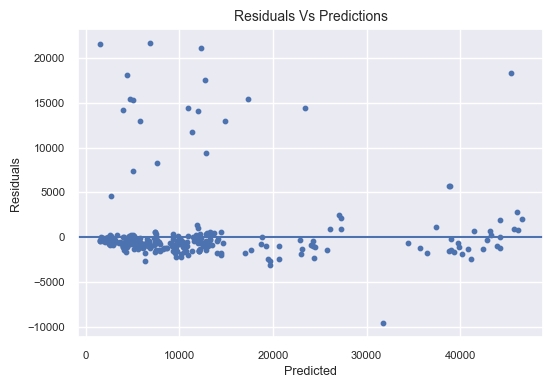

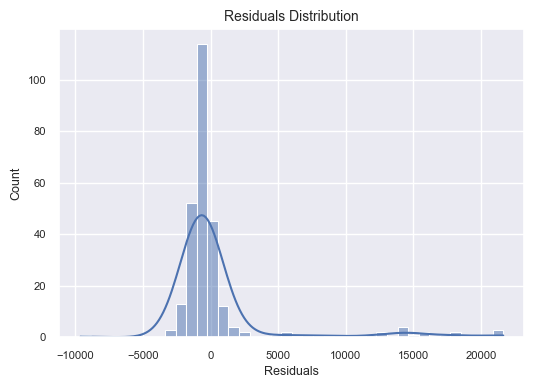

In [114]:
# Residual plot
residuals = y_test - test_final_pred

plt.figure(figsize=(6,4))
plt.scatter(test_final_pred, residuals, s=10)
plt.axhline(0)
plt.title("Residuals Vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()


plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Count")
plt.show()

**10 Building a predictive model**

In [115]:
def predict_insurance_charges(
        model,
        age:float,
        sex:str,
        bmi:float,
        children:int,
        smoker:str,
        region:str
) -> float:
    
    new_row = pd.DataFrame([{
        "age":age,
        "sex":sex,
        "bmi": bmi,
        "children": children,
        "smoker": smoker,
        "region": region
    }])

    return float(model.predict(new_row)[0])

In [116]:
pred = predict_insurance_charges(
    rf_best_log,
    age=35,
    sex="male",
    bmi=29.5,
    children=2,
    smoker="no",
    region="southeast"
)

print("Predicted Medical Insurance cost", round(pred, 2))

Predicted Medical Insurance cost 6238.69
